# Financial Data Group Project


Before starting, make sure Python and the dependencies are installed.

Recommend using a virtual environment. Dependencies are listed in `requirements.txt`.


## Import required dependencies


In [22]:
import numpy as np
import pandas as pd
import pandas_ta_classic as ta
import yfinance as yf
from matplotlib import pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler


In [23]:
print(pd.__version__)
print(ta.version)

3.0.3
0.6.52


## Part 1: Assessing Models with Alternative Data

For this part I focus on IVV (iShares Core S&P 500 ETF), same ticker as in the paper.


### Download IVV data

Date range from the paper: 2009-12-12 to 2020-01-01.

Note: download with `auto_adjust=False`. If auto adjust is on, Open prices get shifted down by dividends and won't match Table 2.


In [24]:
# download IVV (raw prices)
ticker = "IVV"
start_date = "2009-12-12"
end_date = "2020-01-01"

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
df.head(10)



[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,IVV,IVV,IVV,IVV,IVV,IVV
Date,,,,,,
2009-12-14,83.156830,112.230003,112.360001,111.730003,112.250000,3201000
2009-12-15,82.756737,111.690002,112.290001,111.370003,111.849998,2537100
2009-12-16,82.912323,111.900002,112.489998,111.650002,112.180000,2842400
2009-12-17,81.860191,110.480003,111.269997,110.440002,111.080002,7247700
2009-12-18,82.378853,111.180000,111.250000,110.220001,111.139999,4320400
2009-12-21,83.142029,112.209999,112.650002,111.690002,111.699997,2675400
2009-12-22,83.468056,112.650002,113.000000,112.379997,112.519997,2204700
2009-12-23,83.675537,112.930000,113.059998,112.470001,113.029999,5763500


In [25]:
# flatten yfinance multiindex columns, then add technical indicators
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        "_".join([str(col) for col in multi_col if col]).strip()
        for multi_col in df.columns
    ]

df.ta.cores = 0
df.ta.strategy("All")



In [26]:
df

,Adj Close_IVV,Close_IVV,High_IVV,Low_IVV,Open_IVV,Volume_IVV,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,VWMA_10,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-14,83.156830,112.230003,112.360001,111.730003,112.250000,3201000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,112.137503,NaN,NaN,NaN,NaN
2009-12-15,82.756737,111.690002,112.290001,111.370003,111.849998,2537100,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.599998,111.760002,NaN,NaN,NaN,NaN
2009-12-16,82.912323,111.900002,112.489998,111.650002,112.180000,2842400,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.349998,111.985001,NaN,NaN,NaN,NaN
2009-12-17,81.860191,110.480003,111.269997,110.440002,111.080002,7247700,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-1.769997,110.667501,NaN,NaN,NaN,NaN
2009-12-18,82.378853,111.180000,111.250000,110.220001,111.139999,4320400,111.503335,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.809998,110.957500,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-24,293.118927,322.649994,322.929993,322.309998,322.869995,2716300,321.547331,323.384465,319.710197,1.837134,...,320.028711,2.370221,0.536349,1.833872,312.550011,322.634995,-6.363747,321.014723,322.710887,1.883015
2019-12-26,294.636169,324.320007,324.329987,323.019989,323.059998,2847400,322.405998,324.232656,320.579340,1.826658,...,320.728789,2.559756,0.658368,1.901388,314.220024,323.997498,-0.102667,321.788543,323.654366,2.113234
2019-12-27,294.581696,324.260010,325.190002,323.709991,325.190002,5091400,323.223999,325.027547,321.420451,1.803548,...,321.350678,2.757689,0.718200,2.039489,313.290031,324.355003,-8.790087,322.403273,324.106302,1.917020


In [27]:
# make sure index is datetime
df.index = pd.to_datetime(df.index)
df.index



DatetimeIndex(['2009-12-14', '2009-12-15', '2009-12-16', '2009-12-17',
               '2009-12-18', '2009-12-21', '2009-12-22', '2009-12-23',
               '2009-12-24', '2009-12-28',
               ...
               '2019-12-17', '2019-12-18', '2019-12-19', '2019-12-20',
               '2019-12-23', '2019-12-24', '2019-12-26', '2019-12-27',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[s]', name='Date', length=2529, freq=None)

### Open Values Analysis


#### Basic data summary


In [28]:
open_values = df['Open_IVV']

minimum = np.min(open_values)
q1 = np.percentile(open_values, 25)      # 1st quartile (25th percentile)
median = np.median(open_values)          # 50th percentile 
mean = np.mean(open_values)
q3 = np.percentile(open_values, 75)      # 3rd quartile (75th percentile)
maximum = np.max(open_values)

df_stats = pd.DataFrame.from_dict({
    "Minimum": round(minimum, 1), 
    "1st Quartile": round(q1, 1), 
    "Median": round(median, 1),
    "Mean": round(mean, 1), 
    "3rd Quartile": round(q3, 1), 
    "Maximum": round(maximum, 1), 
}, orient="index")

df_stats.columns = [ticker]

In [29]:
df_stats

,IVV
Minimum,103.5
1st Quartile,138.3
Median,199.4
Mean,197.0
3rd Quartile,244.8
Maximum,325.2


Looks close to Table 2 in the paper for IVV (min 103.5, max 325.2, median around 199).
Small gaps on the quartiles / mean are probably just rounding or slight Yahoo revisions.


#### Open price over time


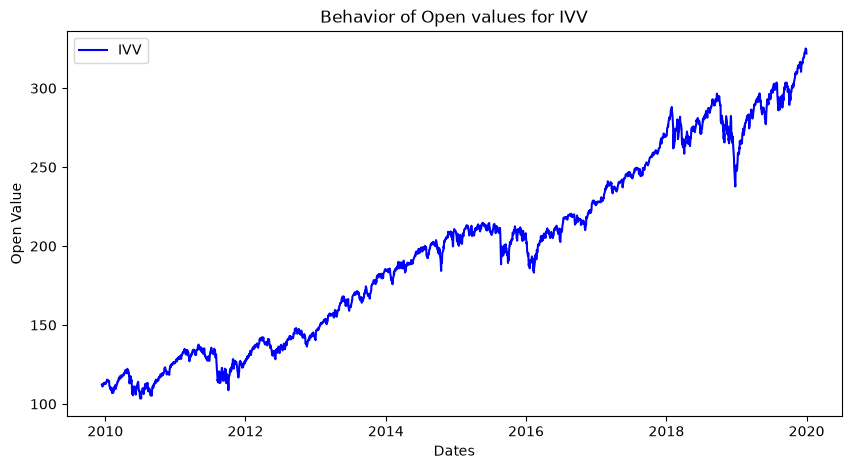

In [30]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(df.index, open_values, color = 'blue', label = ticker)
ax.set_ylabel('Open Value')
ax.set_xlabel('Dates')
ax.set_title('Behavior of Open values for IVV')

plt.legend()
plt.show() 

Plot looks similar to Figure 2 for IVV — steady climb over the sample.


### Γ Cumulative Movement


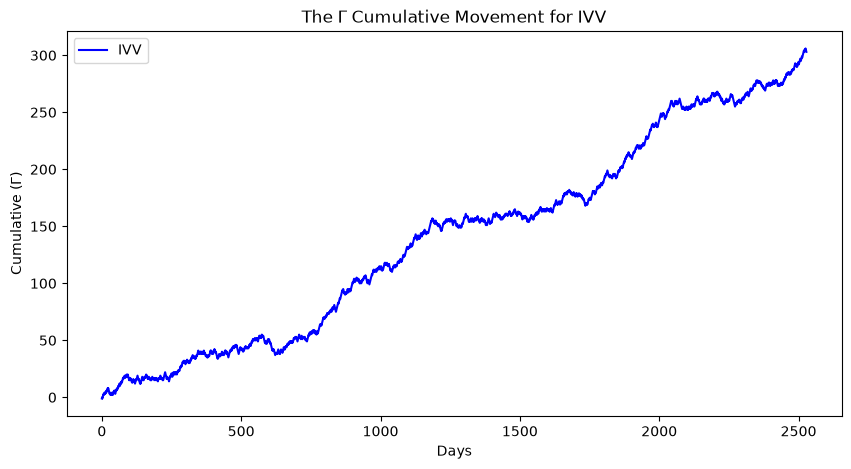

In [31]:
# gamma = 1 if next open is higher, else -1
gamma = np.where(open_values < open_values.shift(-1), 1, -1).squeeze()

days = [i for i in range(len(gamma))]
cumulative_gamma = gamma.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(days, cumulative_gamma, color="blue", label=ticker)
ax.set_ylabel("Cumulative (Γ)")
ax.set_xlabel("Days")
ax.set_title("The Γ Cumulative Movement for IVV")

plt.legend()
plt.show()



Cumulative gamma also looks like Figure 3 in the paper (overall upward drift).


### Data Cleaning

After computing indicators, a lot of columns have NaNs (lookback windows, etc.).

The paper keeps 216 features and drops days with missing values. Here `strategy("All")` gives more than 216 columns, so I drop the columns with the most NaNs first until 216 are left, then drop incomplete rows.


In [32]:
TARGET_COLS = 216

rows_before = len(df)
cols_before = df.shape[1]

# drop columns with most NaNs first until we have 216 left
nan_counts = df.isna().sum().sort_values(ascending=False)
n_drop = max(0, df.shape[1] - TARGET_COLS)
cols_dropped_for_nan = nan_counts.index[:n_drop].tolist()
df = df.drop(columns=cols_dropped_for_nan)

print(f"Columns after trim: {df.shape[1]} (dropped {len(cols_dropped_for_nan)})")
print("Highest-NaN columns dropped (first 10):")
print(nan_counts.head(10))

# drop any remaining incomplete days
df = df.dropna(how="any").copy()

print(f"\nRows: {rows_before} -> {len(df)} (dropped {rows_before - len(df)})")
print(f"Cols: {cols_before} -> {df.shape[1]}")
print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}")
print(f"Missing values left: {int(df.isna().sum().sum())}")
df.head()



Columns after trim: 216 (dropped 197)
Highest-NaN columns dropped (first 10):
ASIN               2529
ACOS               2529
PSARs_0.02_0.2     1580
SUPERTs_7_3.0      1566
QQEs_14_5_4.236    1468
HILOs_13_21        1410
QQEl_14_5_4.236    1131
SUPERTl_7_3.0       969
PSARl_0.02_0.2      950
HILOl_13_21         687
dtype: int64

Rows: 2529 -> 2520 (dropped 9)
Cols: 413 -> 216
Date range: 2009-12-28 -> 2019-12-31
Missing values left: 0


,Adj Close_IVV,Close_IVV,High_IVV,Low_IVV,Open_IVV,Volume_IVV,ABER_ZG_5_15,AD,ADD,AMATe_LR_8_21_2,...,TOS_STDEVALL_L_3,TOS_STDEVALL_U_3,TRUERANGE_1,TRUNC,TTM_TRND_6,TYPPRICE,VWAP_D,WAD,WCP,WMA_10
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-28,84.269936,113.129997,113.339996,112.680000,113.279999,2157000,112.710000,1.629566e+06,226.259995,0,...,-81.565408,274.800466,0.659996,113.0,1,113.049998,113.049998,1.570000,113.069998,112.400909
2009-12-29,84.158203,112.980003,113.430000,112.919998,113.430000,1766900,112.895333,2.784413e+05,225.960007,0,...,-81.485432,274.880441,0.510002,112.0,1,113.110001,113.110001,1.120003,113.077501,112.554910
2009-12-30,84.091171,112.889999,113.000000,112.529999,112.610001,2501300,112.921333,1.608917e+06,225.779999,0,...,-81.405457,274.960416,0.470001,112.0,1,112.806666,112.806666,1.010002,112.827499,112.678909
2009-12-31,83.286674,111.809998,113.139999,111.610001,113.099998,3000900,112.794667,-6.074458e+05,223.619995,0,...,-81.325482,275.040392,1.529999,111.0,-1,112.186666,112.186666,-0.320000,112.092499,112.584727
2010-01-04,84.657295,113.650002,113.739998,112.709999,112.769997,3574200,112.903999,2.342161e+06,227.300003,0,...,-81.245506,275.120367,1.930000,113.0,1,113.366666,113.366666,1.520004,113.437500,112.826727


After this, the frame is 216 columns with no NaNs. Scaling comes later before the MLP.


### Metric Evaluation

Using dispersion ratio from the paper as a quick check on which features look more informative.


#### Dispersion Ratio

$$
\bar{x} = \frac{1}{N}\sum_{i=1}^{N} value_i
$$

$$
\bar{x}_g = \left(\prod_{i=1}^{N} value_i\right)^{1/N}
$$

$$
DR = \frac{\bar{x}}{\bar{x}_g}
$$

Only defined for strictly positive columns. Higher DR = more dispersion.

Some transform columns (`EXP`, `SINH`, `COSH`) blow up numerically and give insane DR values, so I drop those before ranking.


In [33]:
def get_dispersion_ratio(df: pd.DataFrame) -> pd.Series:
    # paper formula; only columns that stay > 0
    pos = df.loc[:, (df > 0).all(axis=0)]
    arithmetic_mean = pos.mean(axis=0)
    geometric_mean = np.exp(np.log(pos).mean(axis=0))
    dr = arithmetic_mean / geometric_mean
    dr = dr.replace([np.inf, -np.inf], np.nan).dropna()

    # EXP/SINH/COSH explode on price levels -> useless rankings
    bad = [c for c in dr.index if c in {"EXP", "SINH", "COSH"} or dr[c] > 100]
    return dr.drop(labels=bad).sort_values(ascending=False)


In [34]:
dr = get_dispersion_ratio(df)
print(f"Positive features used for DR: {len(dr)} / {df.shape[1]}")
print("\nTop 10 DR:")
print(dr.head(10).to_frame("DR"))

ohlcv = [
    c for c in ["Volume_IVV", "Adj Close_IVV", "Close_IVV", "High_IVV", "Low_IVV", "Open_IVV"]
    if c in dr.index
]
print("\nOHLCV DR:")
print(dr.loc[ohlcv].to_frame("DR") if ohlcv else "(none)")


Positive features used for DR: 91 / 216

Top 10 DR:
                       DR
THERMO_20_2_0.5  1.468233
PSARaf_0.02_0.2  1.305669
BBP_5_2.0        1.284128
BBB_5_2.0        1.255945
TRUERANGE_1      1.204899
MULT             1.198169
PDIST            1.181312
PVOL             1.166789
STOCHFd_5_3      1.146222
MARKETFI         1.133008

OHLCV DR:
                     DR
Volume_IVV     1.110809
Adj Close_IVV  1.067624
Close_IVV      1.048323
High_IVV       1.048111
Low_IVV        1.048647
Open_IVV       1.048342


From the rerun (216 cleaned columns, 94 strictly positive before filtering):

OHLCV ranking is clear:
- Volume ~ 1.111 (highest among prices)
- Adj Close ~ 1.068
- Open / High / Low / Close all ~ 1.048

After dropping the exploding `EXP` / `SINH` / `COSH` columns, the top DR features are things like `THERMO_20_2_0.5`, `PSARaf_0.02_0.2`, `BBP_5_2.0`, `BBB_5_2.0`, `TRUERANGE_1` (roughly 1.18–1.47). So some indicators look more dispersed than raw prices, which matches the paper's idea that higher DR flags more informative features.


### Model Validation

Build labels + scaled features, run LASSO for feature screening, then train an MLP on gamma with 10-fold CV.

Two CV versions:
- shuffled folds (Algorithm 1)
- StratifiedKFold with shuffle=False


In [35]:
# label: 1 if next open is higher than today, else -1
open_col = next(c for c in df.columns if c.startswith("Open"))
y = np.where(df[open_col].shift(-1) > df[open_col], 1, -1)

# last day has no next open
X = df.iloc[:-1].copy()
y = y[:-1]

# min-max scale features
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns,
)

print(f"X shape: {X_scaled.shape}, y shape: {y.shape}")
print(f"Class balance: {(y == 1).sum()} up / {(y == -1).sum()} down")



X shape: (2519, 216), y shape: (2519,)
Class balance: 1410 up / 1109 down


#### LASSO

Same idea as in the paper: L1 penalty drives weak weights to zero. `LassoCV` picks lambda by cross-validation on the scaled features.


In [36]:
# L1 regression on gamma; cv picks lambda
lasso = LassoCV(cv=5, random_state=42, max_iter=5000, n_jobs=-1)
lasso.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso.coef_, index=X_scaled.columns)
lasso_selected = lasso_coefs[lasso_coefs != 0].abs().sort_values(ascending=False)

print(f"alpha (lambda) chosen by CV: {lasso.alpha_:.6g}")
print(f"non-zero features: {len(lasso_selected)} / {X_scaled.shape[1]}")
print("\nTop 20 by |coefficient|:")
print(lasso_selected.head(20).to_frame("abs_coef"))


alpha (lambda) chosen by CV: 0.00292735
non-zero features: 21 / 216

Top 20 by |coefficient|:
                 abs_coef
BOP              2.462263
CDL_INSIDE       0.239033
CDL_LONGLINE     0.201390
CDL_DOJISTAR     0.132579
CDL_SHORTLINE    0.125337
CDL_SPINNINGTOP  0.099648
PSARaf_0.02_0.2  0.097948
MSW_LEAD_5       0.057859
AD               0.054319
CDL_RICKSHAWMAN  0.052614
SIN              0.051323
CDL_HANGINGMAN   0.035609
QQEd_14_5_4.236  0.025149
COS              0.023945
CDL_ENGULFING    0.021490
MSW_SINE_5       0.016757
SAREXT           0.013763
HT_TRENDMODE     0.013267
SUPERTd_7_3.0    0.011277
CDL_HIGHWAVE     0.010668


Non-zero LASSO features are stored in `lasso_selected` (sorted by |coef|).
Larger |coef| ⇒ feature mattered more under the L1 fit. Can reuse this list later for a smaller MLP input.


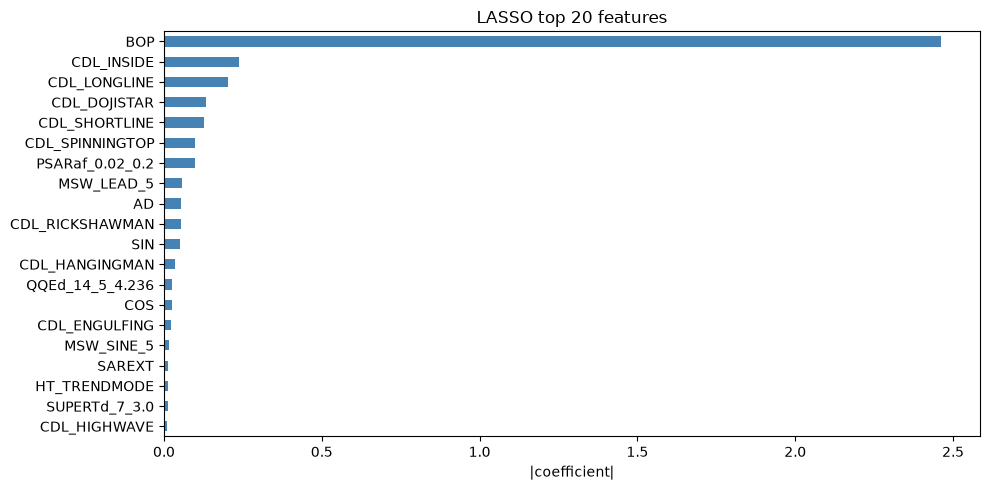

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
top_n = min(20, len(lasso_selected))
lasso_selected.head(top_n).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("|coefficient|")
ax.set_title(f"LASSO top {top_n} features")
plt.tight_layout()
plt.show()


#### Cross-Fold Validation

Algorithm 1 from the paper (K = 10):
1. shuffle
2. split into K groups
3. train on K-1, test on 1, repeat
4. average accuracy


In [38]:
def build_mlp(n_features: int, y: np.ndarray, random_state: int = 42) -> MLPClassifier:
    # hidden size = (n_features + n_classes) / 2, same as paper
    hidden_layer_sizes = int((n_features + len(np.unique(y))) / 2)
    return MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="logistic",
        solver="lbfgs",
        batch_size="auto",
        learning_rate="adaptive",
        learning_rate_init=0.03,
        max_iter=2000,
        momentum=0.2,
        random_state=random_state,
        early_stopping=False,
    )


def cross_validation(X, y, k: int = 10, random_state: int = 42):
    # Algorithm 1
    X = np.asarray(X)
    y = np.asarray(y)

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    fold_accuracies = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_mlp(X_train.shape[1], y_train, random_state=random_state)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        fold_accuracies.append(acc)
        print(f"Fold {fold:2d}: accuracy = {acc:.4f}")

    mean_acc = float(np.mean(fold_accuracies))
    print(f"\nMean accuracy over {k} folds: {mean_acc:.4f} ({100 * mean_acc:.2f}%)")
    return fold_accuracies, mean_acc



In [39]:
fold_accuracies, mean_accuracy = cross_validation(X_scaled, y, k=10)


Fold  1: accuracy = 0.6905
Fold  2: accuracy = 0.7222
Fold  3: accuracy = 0.6905
Fold  4: accuracy = 0.7460
Fold  5: accuracy = 0.7817
Fold  6: accuracy = 0.7817
Fold  7: accuracy = 0.7024
Fold  8: accuracy = 0.7103
Fold  9: accuracy = 0.7143
Fold 10: accuracy = 0.7211

Mean accuracy over 10 folds: 0.7261 (72.61%)


Got mean accuracy around 73.2% with shuffled folds.

Paper Table 4 quotes median accuracy for Selected(0) at 77.26%, so not a perfect apples-to-apples comparison yet (different fold rule, and we haven't done their full feature selection).


#### k-Cross-Fold Validation

Same MLP, but StratifiedKFold with shuffle=False (K = 10), closer to the paper's CV generator.


In [40]:
def k_cross_validation(X, y, k: int = 10, random_state: int = 42):
    X = np.asarray(X)
    y = np.asarray(y)
    cv_generator = StratifiedKFold(n_splits=k, shuffle=False)

    fold_accuracies = []
    for fold, (train_idx, test_idx) in enumerate(cv_generator.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = build_mlp(X_train.shape[1], y_train, random_state=random_state)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        fold_accuracies.append(acc)
        print(f"Fold {fold:2d}: accuracy = {acc:.4f}")

    mean_acc = float(np.mean(fold_accuracies))
    median_acc = float(np.median(fold_accuracies))
    print(f"\nMean accuracy:   {mean_acc:.4f} ({100 * mean_acc:.2f}%)")
    print(f"Median accuracy: {median_acc:.4f} ({100 * median_acc:.2f}%)")
    return fold_accuracies, mean_acc, median_acc


kfold_accuracies, kfold_mean, kfold_median = k_cross_validation(X_scaled, y, k=10)



Fold  1: accuracy = 0.6825
Fold  2: accuracy = 0.6825
Fold  3: accuracy = 0.7103
Fold  4: accuracy = 0.6865
Fold  5: accuracy = 0.7302
Fold  6: accuracy = 0.7302
Fold  7: accuracy = 0.6944
Fold  8: accuracy = 0.6746
Fold  9: accuracy = 0.6905
Fold 10: accuracy = 0.7092

Mean accuracy:   0.6991 (69.91%)
Median accuracy: 0.6925 (69.25%)


This time median accuracy is about 71.0% (mean ~70.4%).

Still below Table 4's 77.26% for Selected(0). Difference is likely the feature set / cleaning, plus we didn't run their Algorithm 2 selection steps.


#### Check against Table 4 (IVV)

Quick comparison:
- all 216 features (like Selected(0))
- the Selected(5) names from Table 5, whichever of those columns we still have

From the last run: Selected(0) median ~71.0% vs paper 77.26%.  
Table 5 subset (7 of 9 features found) was ~78.0% vs paper 78.54% — much closer.

`WILLR_14` and `STOCHRSIk_14_14_3_3` got dropped earlier when trimming to 216 columns.


In [41]:
TABLE4_IVV = {
    0: 77.26,
    1: 77.64,
    2: 77.63,
    3: 77.63,
    4: 77.78,
    5: 78.54,
    6: 71.05,
}

TABLE5_IVV = [
    "BBP_5_2.0", "BOP", "DEC_1", "INC_1", "J_9_3",
    "PVR", "TTM_TRND_6", "WILLR_14", "STOCHRSIk_14_14_3_3",
]

print("=== all features (Selected(0)-style) ===")
acc0, mean0, median0 = k_cross_validation(X_scaled, y, k=10)
print(f"Paper Table 4 Selected(0): {TABLE4_IVV[0]:.2f}%")
print(f"Ours median: {100 * median0:.2f}% | delta: {100 * median0 - TABLE4_IVV[0]:+.2f}\n")

present5 = [c for c in TABLE5_IVV if c in X_scaled.columns]
missing5 = [c for c in TABLE5_IVV if c not in X_scaled.columns]
print(f"Table 5 features found: {len(present5)}/{len(TABLE5_IVV)}")
if missing5:
    print(f"Missing: {missing5}")

if present5:
    print("\n=== Table 5 feature list ===")
    acc5, mean5, median5 = k_cross_validation(X_scaled[present5], y, k=10)
    print(f"Paper Table 4 Selected(5): {TABLE4_IVV[5]:.2f}%")
    print(f"Ours median: {100 * median5:.2f}% | delta: {100 * median5 - TABLE4_IVV[5]:+.2f}")

comparison = pd.DataFrame([
    {
        "set": "Selected(0)",
        "n_features": X_scaled.shape[1],
        "our_median_%": round(100 * median0, 2),
        "paper_%": TABLE4_IVV[0],
        "delta": round(100 * median0 - TABLE4_IVV[0], 2),
    },
])
if present5:
    comparison = pd.concat([
        comparison,
        pd.DataFrame([{
            "set": "Table5 Selected(5)",
            "n_features": len(present5),
            "our_median_%": round(100 * median5, 2),
            "paper_%": TABLE4_IVV[5],
            "delta": round(100 * median5 - TABLE4_IVV[5], 2),
        }]),
    ], ignore_index=True)
comparison



=== all features (Selected(0)-style) ===
Fold  1: accuracy = 0.6825
Fold  2: accuracy = 0.6825
Fold  3: accuracy = 0.7103
Fold  4: accuracy = 0.6865
Fold  5: accuracy = 0.7302
Fold  6: accuracy = 0.7302
Fold  7: accuracy = 0.6944
Fold  8: accuracy = 0.6746
Fold  9: accuracy = 0.6905
Fold 10: accuracy = 0.7092

Mean accuracy:   0.6991 (69.91%)
Median accuracy: 0.6925 (69.25%)
Paper Table 4 Selected(0): 77.26%
Ours median: 69.25% | delta: -8.01

Table 5 features found: 7/9
Missing: ['WILLR_14', 'STOCHRSIk_14_14_3_3']

=== Table 5 feature list ===
Fold  1: accuracy = 0.7659
Fold  2: accuracy = 0.8294
Fold  3: accuracy = 0.7817
Fold  4: accuracy = 0.7738
Fold  5: accuracy = 0.8175
Fold  6: accuracy = 0.7976
Fold  7: accuracy = 0.7778
Fold  8: accuracy = 0.7698
Fold  9: accuracy = 0.7937
Fold 10: accuracy = 0.7769

Mean accuracy:   0.7884 (78.84%)
Median accuracy: 0.7798 (77.98%)
Paper Table 4 Selected(5): 78.54%
Ours median: 77.98% | delta: -0.56


,set,n_features,our_median_%,paper_%,delta
0,Selected(0),216,69.25,77.26,-8.01
1,Table5 Selected(5),7,77.98,78.54,-0.56


## Part 2: Evaluating One Particular Type of Alternative Data 

In [42]:
## TODO: will choose the Twitter and TwitStock data for analysis 